# Nasdaq API Scraping

In [1]:
import requests
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pycountry

# import local module <app_config.py>
from app_config import get_api # from app_config <module> import get_api <class> 


## Set up the API 

In [2]:
# get API Key
API_KEY = get_api.API_KEY

In [3]:
# get the api endpoint from Nasdaq Data Link Website
api_url = 'https://data.nasdaq.com/api/v3/datatables/MER/F1.json'

#setting up parameters
parameters = {
    'api_key': API_KEY,
    # n rows of data to be pulled, currently limited to 1e+4
    'qopts.per_page': 10000
}

## Scrape the data 

In [4]:
json_data = requests.get(api_url, params=parameters).json()
json_data

{'datatable': {'data': [[2438,
    1868192544,
    -1802,
    10.481948,
    '2011-06-30',
    'Q2',
    'U',
    'EUR',
    'True',
    'Deutsche Bank AG',
    'Deutsche Bank AG',
    'Active',
    'DEU',
    'Europe',
    1159508,
    '5.1.1',
    'DB',
    'NYS',
    'Taunusanlage 12',
    None,
    None,
    None,
    'Frankfurt am Main',
    None,
    'DEU',
    '60325',
    '(49) 69 910 00',
    '(49) 69 910 34 225',
    'www.db.com',
    '2024-12-31',
    'Accrued Expenses Turnover',
    'Derived'],
   [2438,
    1868216112,
    -1802,
    8.161754,
    '2011-09-30',
    'Q3',
    'U',
    'EUR',
    'True',
    'Deutsche Bank AG',
    'Deutsche Bank AG',
    'Active',
    'DEU',
    'Europe',
    1159508,
    '5.1.1',
    'DB',
    'NYS',
    'Taunusanlage 12',
    None,
    None,
    None,
    'Frankfurt am Main',
    None,
    'DEU',
    '60325',
    '(49) 69 910 00',
    '(49) 69 910 34 225',
    'www.db.com',
    '2024-12-31',
    'Accrued Expenses Turnover',
    'Derived']

In [5]:
# extract relevant data
data = json_data['datatable']['data']
data

[[2438,
  1868192544,
  -1802,
  10.481948,
  '2011-06-30',
  'Q2',
  'U',
  'EUR',
  'True',
  'Deutsche Bank AG',
  'Deutsche Bank AG',
  'Active',
  'DEU',
  'Europe',
  1159508,
  '5.1.1',
  'DB',
  'NYS',
  'Taunusanlage 12',
  None,
  None,
  None,
  'Frankfurt am Main',
  None,
  'DEU',
  '60325',
  '(49) 69 910 00',
  '(49) 69 910 34 225',
  'www.db.com',
  '2024-12-31',
  'Accrued Expenses Turnover',
  'Derived'],
 [2438,
  1868216112,
  -1802,
  8.161754,
  '2011-09-30',
  'Q3',
  'U',
  'EUR',
  'True',
  'Deutsche Bank AG',
  'Deutsche Bank AG',
  'Active',
  'DEU',
  'Europe',
  1159508,
  '5.1.1',
  'DB',
  'NYS',
  'Taunusanlage 12',
  None,
  None,
  None,
  'Frankfurt am Main',
  None,
  'DEU',
  '60325',
  '(49) 69 910 00',
  '(49) 69 910 34 225',
  'www.db.com',
  '2024-12-31',
  'Accrued Expenses Turnover',
  'Derived'],
 [2438,
  1885063456,
  -1802,
  10.788213,
  '2012-06-30',
  'Q2',
  'U',
  'EUR',
  'True',
  'Deutsche Bank AG',
  'Deutsche Bank AG',
  'Active

In [6]:
# get the list of column names using list comprehension
columns = [col['name'] for col in json_data['datatable']['columns']]

# create the dataframe
df = pd.DataFrame(data, columns=columns)
df

,compnumber,reportid,mapcode,amount,reportdate,reporttype,auditorstatus,currency,consolidated,longname,...,city,statecode,country,zipcode,phonenumber,faxnumber,website,fye,indicator,statement
0,2438,1868192544,-1802,1.048195e+01,2011-06-30,Q2,U,EUR,True,Deutsche Bank AG,...,Frankfurt am Main,None,DEU,60325,(49) 69 910 00,(49) 69 910 34 225,www.db.com,2024-12-31,Accrued Expenses Turnover,Derived
1,2438,1868216112,-1802,8.161754e+00,2011-09-30,Q3,U,EUR,True,Deutsche Bank AG,...,Frankfurt am Main,None,DEU,60325,(49) 69 910 00,(49) 69 910 34 225,www.db.com,2024-12-31,Accrued Expenses Turnover,Derived
2,2438,1885063456,-1802,1.078821e+01,2012-06-30,Q2,U,EUR,True,Deutsche Bank AG,...,Frankfurt am Main,None,DEU,60325,(49) 69 910 00,(49) 69 910 34 225,www.db.com,2024-12-31,Accrued Expenses Turnover,Derived
3,2438,1885087024,-1802,9.437545e+00,2012-09-30,Q3,U,EUR,True,Deutsche Bank AG,...,Frankfurt am Main,None,DEU,60325,(49) 69 910 00,(49) 69 910 34 225,www.db.com,2024-12-31,Accrued Expenses Turnover,Derived
4,2438,1901934112,-1802,8.755041e+00,2013-06-30,Q2,U,EUR,True,Deutsche Bank AG,...,Frankfurt am Main,None,DEU,60325,(49) 69 910 00,(49) 69 910 34 225,www.db.com,2024-12-31,Accrued Expenses Turnover,Derived
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,76258,1593770752,-4049,8.060000e+08,2014-09-30,Q3,U,USD,True,Chubb Ltd,...,Zurich,None,CHE,CH-8001,(41) 43 456 7600,None,www.chubb.com,2024-12-31,Cash and Equivalents,Balance Sheet
9996,76258,1593770752,-1766,2.115900e-01,2014-09-30,Q3,U,USD,True,Chubb Ltd,...,Zurich,None,CHE,CH-8001,(41) 43 456 7600,None,www.chubb.com,2024-12-31,Total Asset Turnover,Derived
9997,76258,1593770752,-9085,5.330200e-02,2014-09-30,Q3,U,USD,True,Chubb Ltd,...,Zurich,None,CHE,CH-8001,(41) 43 456 7600,None,www.chubb.com,2024-12-31,Revenue to Assets,Derived
9998,76258,1593770752,-5009,8.051120e-01,2014-09-30,Q3,U,USD,True,Chubb Ltd,...,Zurich,None,CHE,CH-8001,(41) 43 456 7600,None,www.chubb.com,2024-12-31,Return on Assets,Derived


## Clean the Data

### Filter Unnecessary Columns

In [7]:
necessary_cols = ['reportid', 'reportdate', 'reporttype', 'longname', 'amount', 'currency', 'country', 'region', 'indicator', 'statement']
df = df[necessary_cols]
df

,reportid,reportdate,reporttype,longname,amount,currency,country,region,indicator,statement
0,1868192544,2011-06-30,Q2,Deutsche Bank AG,1.048195e+01,EUR,DEU,Europe,Accrued Expenses Turnover,Derived
1,1868216112,2011-09-30,Q3,Deutsche Bank AG,8.161754e+00,EUR,DEU,Europe,Accrued Expenses Turnover,Derived
2,1885063456,2012-06-30,Q2,Deutsche Bank AG,1.078821e+01,EUR,DEU,Europe,Accrued Expenses Turnover,Derived
3,1885087024,2012-09-30,Q3,Deutsche Bank AG,9.437545e+00,EUR,DEU,Europe,Accrued Expenses Turnover,Derived
4,1901934112,2013-06-30,Q2,Deutsche Bank AG,8.755041e+00,EUR,DEU,Europe,Accrued Expenses Turnover,Derived
...,...,...,...,...,...,...,...,...,...,...
9995,1593770752,2014-09-30,Q3,Chubb Ltd,8.060000e+08,USD,CHE,Europe,Cash and Equivalents,Balance Sheet
9996,1593770752,2014-09-30,Q3,Chubb Ltd,2.115900e-01,USD,CHE,Europe,Total Asset Turnover,Derived
9997,1593770752,2014-09-30,Q3,Chubb Ltd,5.330200e-02,USD,CHE,Europe,Revenue to Assets,Derived
9998,1593770752,2014-09-30,Q3,Chubb Ltd,8.051120e-01,USD,CHE,Europe,Return on Assets,Derived


### Standardize Data

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   reportid    10000 non-null  int64  
 1   reportdate  10000 non-null  object 
 2   reporttype  10000 non-null  object 
 3   longname    10000 non-null  object 
 4   amount      10000 non-null  float64
 5   currency    10000 non-null  object 
 6   country     10000 non-null  object 
 7   region      10000 non-null  object 
 8   indicator   10000 non-null  object 
 9   statement   10000 non-null  object 
dtypes: float64(1), int64(1), object(8)
memory usage: 781.4+ KB


In [9]:
# reportdate Column - date to date-time

df['reportdate'] = pd.to_datetime(df['reportdate'], errors='coerce') # returns NAT(NotATime) if error occurs

df

C:\Users\KOBE\AppData\Local\Temp\ipykernel_11652\3074610107.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['reportdate'] = pd.to_datetime(df['reportdate'], errors='coerce') # returns NAT(NotATime) if error occurs


,reportid,reportdate,reporttype,longname,amount,currency,country,region,indicator,statement
0,1868192544,2011-06-30,Q2,Deutsche Bank AG,1.048195e+01,EUR,DEU,Europe,Accrued Expenses Turnover,Derived
1,1868216112,2011-09-30,Q3,Deutsche Bank AG,8.161754e+00,EUR,DEU,Europe,Accrued Expenses Turnover,Derived
2,1885063456,2012-06-30,Q2,Deutsche Bank AG,1.078821e+01,EUR,DEU,Europe,Accrued Expenses Turnover,Derived
3,1885087024,2012-09-30,Q3,Deutsche Bank AG,9.437545e+00,EUR,DEU,Europe,Accrued Expenses Turnover,Derived
4,1901934112,2013-06-30,Q2,Deutsche Bank AG,8.755041e+00,EUR,DEU,Europe,Accrued Expenses Turnover,Derived
...,...,...,...,...,...,...,...,...,...,...
9995,1593770752,2014-09-30,Q3,Chubb Ltd,8.060000e+08,USD,CHE,Europe,Cash and Equivalents,Balance Sheet
9996,1593770752,2014-09-30,Q3,Chubb Ltd,2.115900e-01,USD,CHE,Europe,Total Asset Turnover,Derived
9997,1593770752,2014-09-30,Q3,Chubb Ltd,5.330200e-02,USD,CHE,Europe,Revenue to Assets,Derived
9998,1593770752,2014-09-30,Q3,Chubb Ltd,8.051120e-01,USD,CHE,Europe,Return on Assets,Derived


In [ ]:
'''
country col - country code to common country name
'''

# extract unique country codes within our data
country_list = df['country'].unique().tolist()

# create a dictionary {code : country name} using dictionary comprehension 
country_dict = {
    code : (
        getattr(c, "common_name", c.name )
        if (c := pycountry.countries.get(alpha_3=code))
        else "Unknown"
    )
    for code in country_list
}

# mapping country codes with country names in our dataframe

df['country'] = df['country'].replace(country_dict)

C:\Users\KOBE\AppData\Local\Temp\ipykernel_11652\2747194533.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['country'] = df['country'].replace(country_dict)


In [11]:
df['country'].replace(country_dict)
df

,reportid,reportdate,reporttype,longname,amount,currency,country,region,indicator,statement
0,1868192544,2011-06-30,Q2,Deutsche Bank AG,1.048195e+01,EUR,Germany,Europe,Accrued Expenses Turnover,Derived
1,1868216112,2011-09-30,Q3,Deutsche Bank AG,8.161754e+00,EUR,Germany,Europe,Accrued Expenses Turnover,Derived
2,1885063456,2012-06-30,Q2,Deutsche Bank AG,1.078821e+01,EUR,Germany,Europe,Accrued Expenses Turnover,Derived
3,1885087024,2012-09-30,Q3,Deutsche Bank AG,9.437545e+00,EUR,Germany,Europe,Accrued Expenses Turnover,Derived
4,1901934112,2013-06-30,Q2,Deutsche Bank AG,8.755041e+00,EUR,Germany,Europe,Accrued Expenses Turnover,Derived
...,...,...,...,...,...,...,...,...,...,...
9995,1593770752,2014-09-30,Q3,Chubb Ltd,8.060000e+08,USD,Switzerland,Europe,Cash and Equivalents,Balance Sheet
9996,1593770752,2014-09-30,Q3,Chubb Ltd,2.115900e-01,USD,Switzerland,Europe,Total Asset Turnover,Derived
9997,1593770752,2014-09-30,Q3,Chubb Ltd,5.330200e-02,USD,Switzerland,Europe,Revenue to Assets,Derived
9998,1593770752,2014-09-30,Q3,Chubb Ltd,8.051120e-01,USD,Switzerland,Europe,Return on Assets,Derived


In [12]:
df['country'].value_counts()

country
United States     3253
Cayman Islands    1556
Japan             1303
Ireland           1155
Bahamas            898
India              608
Switzerland        554
Australia          228
Canada             106
Brazil              62
South Korea         54
United Kingdom      51
France              33
Chile               22
Indonesia           21
Finland             16
Belgium             14
Italy               14
Israel              12
Hong Kong           12
Denmark             12
Germany              8
Spain                8
Name: count, dtype: int64

In [13]:
# standardize column names

df = df.rename(columns={
    'reportid':'report_id', 
    'reportdate':'report_date', 
    'reporttype':'report_type',
    'longname':'company_name' 
    }
    )

df

,report_id,report_date,report_type,company_name,amount,currency,country,region,indicator,statement
0,1868192544,2011-06-30,Q2,Deutsche Bank AG,1.048195e+01,EUR,Germany,Europe,Accrued Expenses Turnover,Derived
1,1868216112,2011-09-30,Q3,Deutsche Bank AG,8.161754e+00,EUR,Germany,Europe,Accrued Expenses Turnover,Derived
2,1885063456,2012-06-30,Q2,Deutsche Bank AG,1.078821e+01,EUR,Germany,Europe,Accrued Expenses Turnover,Derived
3,1885087024,2012-09-30,Q3,Deutsche Bank AG,9.437545e+00,EUR,Germany,Europe,Accrued Expenses Turnover,Derived
4,1901934112,2013-06-30,Q2,Deutsche Bank AG,8.755041e+00,EUR,Germany,Europe,Accrued Expenses Turnover,Derived
...,...,...,...,...,...,...,...,...,...,...
9995,1593770752,2014-09-30,Q3,Chubb Ltd,8.060000e+08,USD,Switzerland,Europe,Cash and Equivalents,Balance Sheet
9996,1593770752,2014-09-30,Q3,Chubb Ltd,2.115900e-01,USD,Switzerland,Europe,Total Asset Turnover,Derived
9997,1593770752,2014-09-30,Q3,Chubb Ltd,5.330200e-02,USD,Switzerland,Europe,Revenue to Assets,Derived
9998,1593770752,2014-09-30,Q3,Chubb Ltd,8.051120e-01,USD,Switzerland,Europe,Return on Assets,Derived


## Analytics

In [15]:
df['indicator'].value_counts()

indicator
EBITDA                                           291
EBITDA Margin                                    289
Total Assets Per Share                           244
Shares Outstanding                               239
Free Cash Flow Per Share                         232
EPS - Net Income - Diluted                       232
Revenue Per Share                                230
EPS - Net Income - Basic                         230
Weighted Average Shares Outstanding - Diluted    228
Weighted Average Shares Outstanding - Basic      227
Cash From Investing                              220
Net Income                                       220
Cash, Beginning of Year                          220
Calculated Tax Rate                              219
Cash, End of Year                                219
Cash From Operations                             219
Total Assets                                     217
Total Revenue                                    217
Net Margin                          

In [ ]:
# create a slice of data frame with the target indicator


### EBITDA Margin

In [16]:
filtered_df = df[df['indicator']=='EBITDA Margin'].copy()
filtered_df.head()

,report_id,report_date,report_type,company_name,amount,currency,country,region,indicator,statement
662,1868192512,2011-06-30,A,Immutep Ltd,-1979.328191,AUD,Australia,Asia Pacific,EBITDA Margin,Derived
768,1918804736,2014-06-30,A,Immutep Ltd,-86142.858937,AUD,Australia,Asia Pacific,EBITDA Margin,Derived
817,1935675392,2015-06-30,A,Immutep Ltd,-19363.385060,AUD,Australia,Asia Pacific,EBITDA Margin,Derived
845,1851368960,2010-12-31,A,Ultrapetrol (Bahamas) Ltd,26.841546,USD,Bahamas,Latin America,EBITDA Margin,Derived
889,1851369024,2010-12-31,Q4,Ultrapetrol (Bahamas) Ltd,14.403761,USD,Bahamas,Latin America,EBITDA Margin,Derived


In [17]:
filtered_df.describe()

,report_id,report_date,amount
count,2.890000e+02,289,289.000000
mean,1.747260e+09,2013-06-26 03:59:10.173010432,-353.917085
min,1.504051e+09,2010-12-31 00:00:00,-86142.858937
25%,1.569850e+09,2011-12-31 00:00:00,13.932416
50%,1.868169e+09,2013-06-30 00:00:00,17.234169
75%,1.901958e+09,2014-11-30 00:00:00,26.044164
max,1.952476e+09,2015-12-31 00:00:00,47.410116
std,1.693446e+08,NaN,5191.939353


Summary shows that the mean is significantly lower (it's in negative) than our 1st quartile.  
It is also highly notable that the range is widely spread.  
Such case suggest that extreme outliers are present in our data.  
Investigation must be done to pinpoint the anomaly.

In [18]:
# sort data frame by amount values
filtered_df.sort_values(by='amount')
filtered_df

,report_id,report_date,report_type,company_name,amount,currency,country,region,indicator,statement
662,1868192512,2011-06-30,A,Immutep Ltd,-1979.328191,AUD,Australia,Asia Pacific,EBITDA Margin,Derived
768,1918804736,2014-06-30,A,Immutep Ltd,-86142.858937,AUD,Australia,Asia Pacific,EBITDA Margin,Derived
817,1935675392,2015-06-30,A,Immutep Ltd,-19363.385060,AUD,Australia,Asia Pacific,EBITDA Margin,Derived
845,1851368960,2010-12-31,A,Ultrapetrol (Bahamas) Ltd,26.841546,USD,Bahamas,Latin America,EBITDA Margin,Derived
889,1851369024,2010-12-31,Q4,Ultrapetrol (Bahamas) Ltd,14.403761,USD,Bahamas,Latin America,EBITDA Margin,Derived
...,...,...,...,...,...,...,...,...,...,...
9258,1605697792,2015-03-31,Q1,Nielsen Holdings PLC,21.604938,USD,United States,Europe,EBITDA Margin,Derived
9275,1611661824,2015-06-30,Q2,Nielsen Holdings PLC,27.325208,USD,United States,Europe,EBITDA Margin,Derived
9339,1617691392,2015-09-30,Q3,Nielsen Holdings PLC,29.196604,USD,United States,Europe,EBITDA Margin,Derived
9381,1623719936,2015-12-31,A,Nielsen Holdings PLC,23.136747,USD,United States,Europe,EBITDA Margin,Derived


Data showed that these extreme negative values were all from the same company, Immutep Ltd.  
A quick search online would tell you that the company was acquired by another company in 2014.  
Although, we failed to find reason for the extreme amount, we shall ommit data from Immutep Ltd from our table.  
This is to avoid extreme outcome in our analysis.

In [20]:
filtered_df = filtered_df[filtered_df['company_name'] != 'Immutep Ltd']
filtered_df.describe()

,report_id,report_date,amount
count,2.860000e+02,286,286.000000
mean,1.745579e+09,2013-06-24 20:28:31.888111872,18.194177
min,1.504051e+09,2010-12-31 00:00:00,-26.841528
25%,1.569850e+09,2012-01-15 00:00:00,14.146726
50%,1.859769e+09,2013-06-29 12:00:00,17.296259
75%,1.901952e+09,2014-11-14 18:00:00,26.055693
max,1.952476e+09,2015-12-31 00:00:00,47.410116
std,1.694033e+08,NaN,13.189965


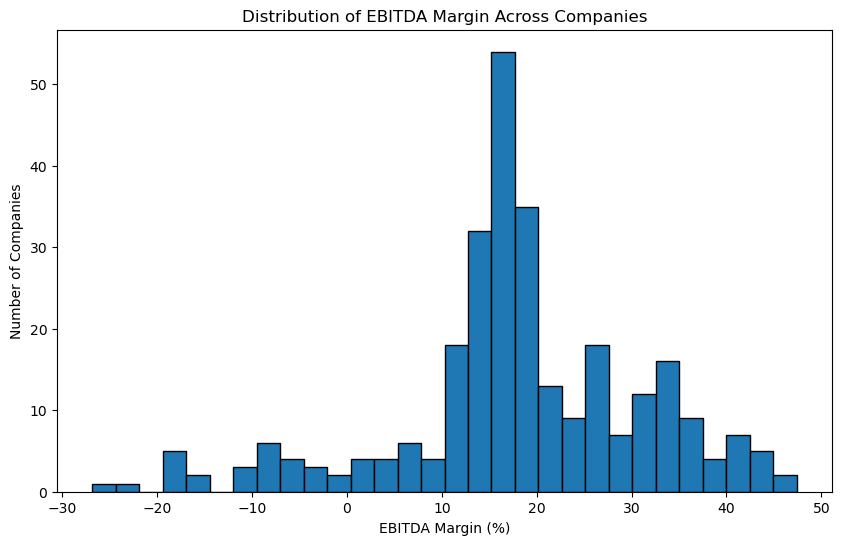

In [27]:
plt.figure(figsize=(10,6))
plt.hist(filtered_df['amount'], bins=30, edgecolor='black')
plt.xlabel('EBITDA Margin (%)')
plt.ylabel('Number of Companies')
plt.title('Distribution of EBITDA Margin Across Companies')
plt.show()

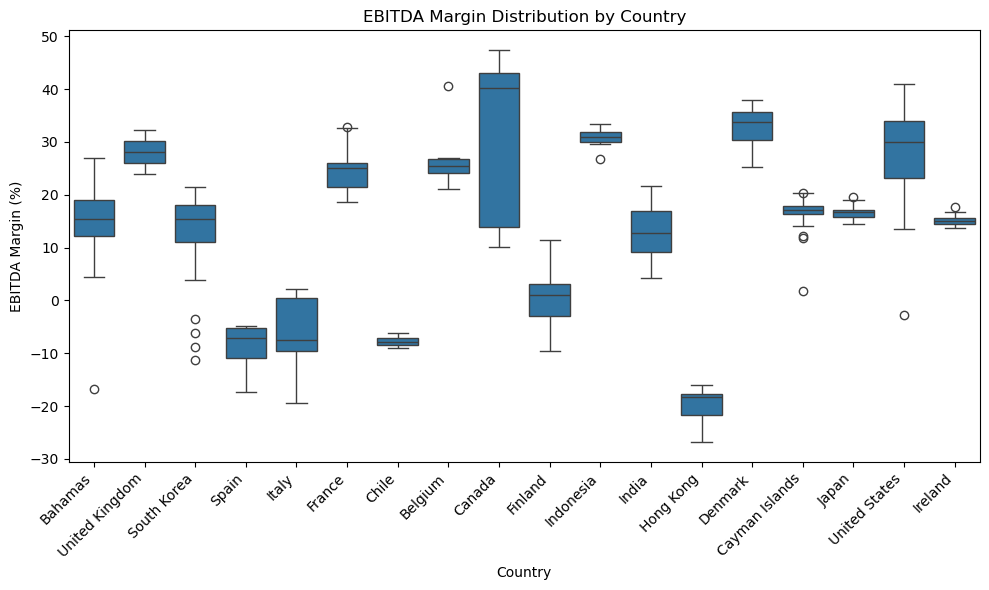

In [ ]:
plt.figure(figsize=(10,6))
ax = sns.boxplot(data=filtered_df, x='country',y='amount')
plt.xlabel('Country')
plt.ylabel('EBITDA Margin (%)')
plt.title('EBITDA Margin Distribution by Country')
plt.xticks(rotation=45,ha='right')
plt.tight_layout()
plt.show()

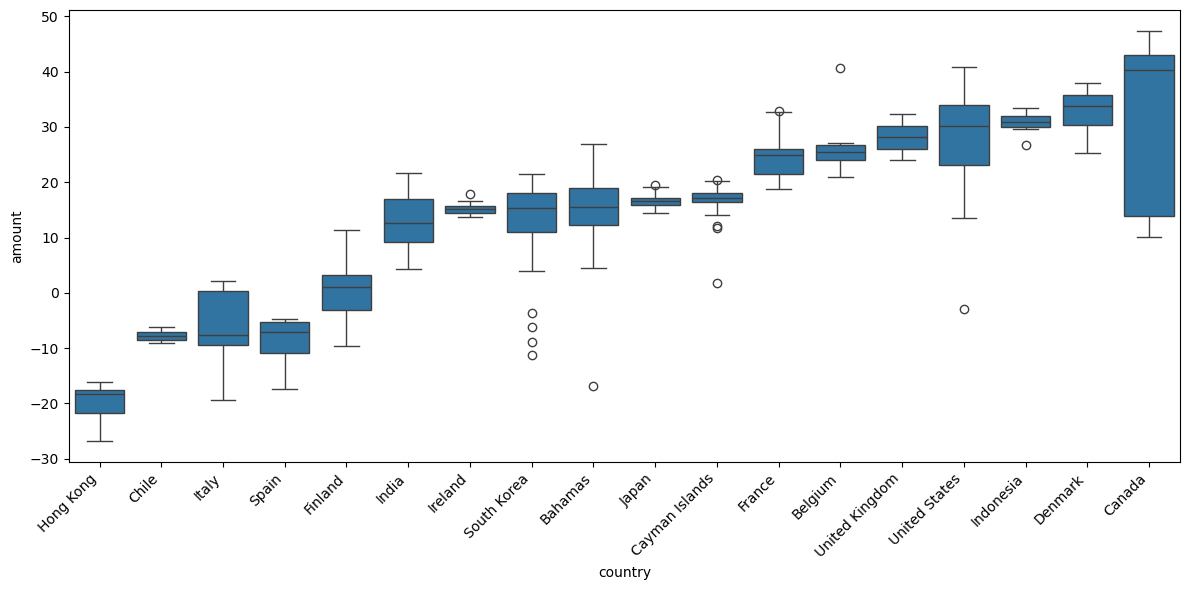

In [37]:
order = filtered_df.groupby('country')['amount'].median().sort_values().index
plt.figure(figsize=(12,6))
sns.boxplot(data=filtered_df, x='country', y='amount', order=order)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

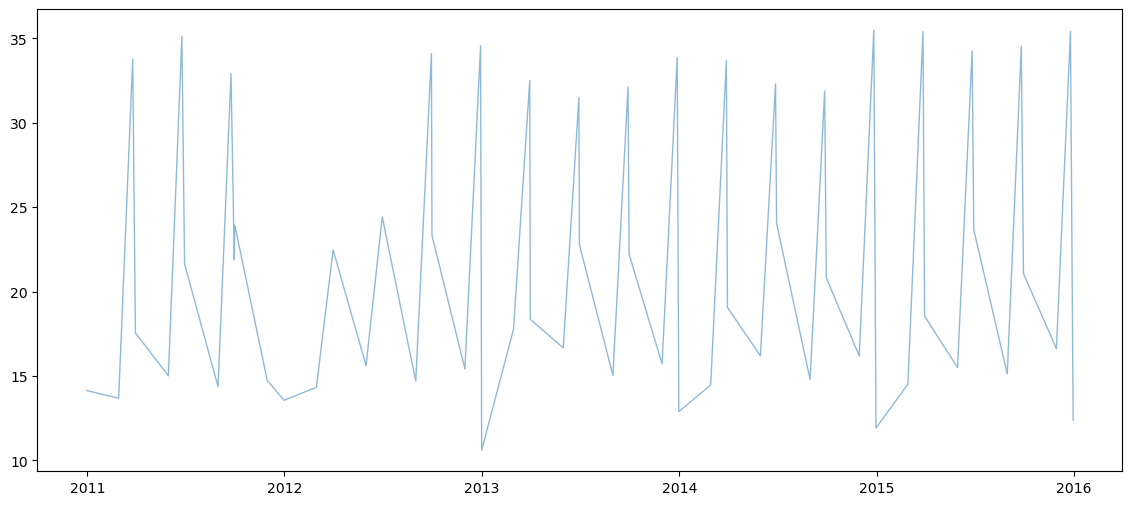

In [36]:
time_trend = filtered_df.groupby('report_date')['amount'].mean()

fig, ax = plt.subplots(figsize=(14,6))

ax.plot(time_trend.index, time_trend.values, alpha=0.5, label='Original', linewidth=1)

### Acrrued Expense Turnover